In [15]:
# capstone project -- function 6 (5D), week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 6

5D, 20 initial points plus 1 collected. **Using UCB with `kappa=0.5`.**



In [16]:
X_initial = np.load("initial_data/function_6/initial_inputs.npy")
y_initial = np.load("initial_data/function_6/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 5, f"Expected a 5D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded, and it is the new best. Clean provenance: the old sweep proposed exactly these coordinates, all positive, none on a bound, and every one inside the range already sampled on its axis.

In [17]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    [0.519691, 0.384667, 0.382026, 0.764661, 0.218558],     # week 2
    [0.371752, 0.146637, 0.75637, 1.545378, 0.0],           # week 3 -- x4 at the floor
])

new_y = np.array([
    -0.5119821356901731,
    -1.2147961781405971,
])

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))
print("-> %s" % ("the WORST observation on record"
                 if new_y[-1] < min(y_initial.min(), new_y[0])
                 else "within the existing range"))


observations collected so far: 2
latest y: -1.214796 | best before it: -0.511982 (change -0.702814)
-> within the existing range


## Build the full dataset (initial + everything collected so far)

In [18]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.6f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# X is known to never be negative -- lower_limit=0.0 is mandatory. Note this
# makes the LOWER bound a real domain constraint, while the upper bounds are
# an artifact of pad_fraction. The checks below treat them differently.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", np.round(bounds, 4))

print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" y={new_y[r]:.6f}")

# The convex hull is a weak notion at D=5 with this many points -- quantify how
# weak, so the check below is read with the right expectations.
try:
    hull = Delaunay(X)
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.1%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices"
          " -- at D=5 nearly all of them are, so the hull test is weak here")
except Exception as exc:
    hull = None
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (20, 5) | combined X shape: (22, 5)
y range: -2.571170 to -0.511982 (spread 2.059187, std 0.476980)

Bounds:
 [[0.     1.8937]
 [0.     1.7493]
 [0.     1.9411]
 [0.     1.8777]
 [0.     1.7807]]

collected points vs the INITIAL batch's range:
  week 2  x0=0.519691  initial range [0.0217, 0.9577]  outside=False
  week 2  x1=0.384667  initial range [0.1144, 0.9319]  outside=False
  week 2  x2=0.382026  initial range [0.0165, 0.9788]  outside=False
  week 2  x3=0.764661  initial range [0.0456, 0.9617]  outside=False
  week 2  x4=0.218558  initial range [0.0049, 0.8928]  outside=False
  -> week 2: 0 of 5 coordinates outside, y=-0.511982
  week 3  x0=0.371752  initial range [0.0217, 0.9577]  outside=False
  week 3  x1=0.146637  initial range [0.1144, 0.9319]  outside=False
  week 3  x2=0.756370  initial range [0.0165, 0.9788]  outside=False
  week 3  x3=1.545378  initial range [0.0456, 0.9617]  outside=True
  week 3  x4=0.000000  initial range [0.0049, 0.8928]  outside=Tru

## Is the model stable and calibrated?

Two checks that were load-bearing on functions 4 and 5, run here as confirmation.

First, refit on the initial batch alone and predict the collected point. That fit never saw it, so this is a genuine out-of-sample test; the miss in units of its own predicted sigma says how much to trust the model's uncertainty. On function 5 this came back at 17 sigma and changed the whole approach.

Second, compare kernels before and after. One observation reshaping the model is a reason to distrust any variance-driven acquisition. Function 4's length-scales tripled from a single point; expect this one to barely move.

In [19]:
gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25, random_state=0)
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is out of sample. The
# model that actually proposed week 3 also had week 2, so this is a lower
# bound on what was known at proposal time for later rows.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.6f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))
print("ratio (after/before):", np.round(ls_after / ls_before, 2))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

if np.max(np.abs(ls_after / ls_before - 1)) > 0.5:
    print("\n*** A length-scale moved by more than 50% from one observation.")
    print("    Treat variance-driven acquisitions with suspicion this week. ***")

out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted -0.596318 +/- 0.149673   actual -0.511982
    miss +0.084336 = +0.6 sigma  -> well calibrated
  week 3: predicted -0.208370 +/- 0.468187   actual -1.214796
    miss -1.006426 = -2.1 sigma  -> well calibrated

kernel before: 2.46**2 * Matern(length_scale=[0.456, 0.936, 1.06, 1.14, 1.22], nu=2.5) + WhiteKernel(noise_level=0.0462)
kernel after : 1.4**2 * Matern(length_scale=[0.295, 0.578, 0.604, 0.527, 0.581], nu=2.5) + WhiteKernel(noise_level=0.00522)

length-scales before: [0.456 0.936 1.064 1.136 1.22 ]
length-scales after : [0.295 0.578 0.604 0.527 0.581]
ratio (after/before): [0.65 0.62 0.57 0.46 0.48]

pinned (GP treats as irrelevant) before: none
pinned after                          : none

*** A length-scale moved by more than 50% from one observation.
    Treat variance-driven acquisitions with suspicion this week. ***


## Which axes matter, and in what way

Two complementary measures, because they answer different questions.

**GP mean-variation** (sweep one axis, others held at the incumbent) asks "how much does the model think this axis moves the response, in any pattern". **Spearman rank correlation** asks "is there a usable monotone direction". An axis can score high on the first and near-zero on the second: that is a non-monotone effect, and it is exactly what x0 shows here (variation 2.02, the shortest length-scale, but rank correlation -0.018). Not a contradiction -- Spearman is blind to non-monotone structure by construction.

The cell also applies the flat-axis rule used on functions 3, 5, 7 and 8: an axis counts as flat if its mean-variation is under 5% of the largest, **or** its length-scale is pinned near the 10.0 ceiling. Flat axes get held at the incumbent instead of searched, because a flat acquisition surface makes their coordinates optimiser artifacts. On this function nothing qualifies, so all five axes are searched -- which is why there is no restricted-search cell here, unlike functions 3, 5, 7 and 8.

In [20]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 6), " y = %.6f" % y.max())

print("\n%3s | %17s | %15s | %8s | %9s | %s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman", "reading"))
spans = np.zeros(D)
for d in range(D):
    row = []
    for lo, hi in [(bounds[d, 0], bounds[d, 1]), (X[:, d].min(), X[:, d].max())]:
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        row.append(m.max() - m.min())
    spans[d] = row[0]
    sr = spearmanr(X[:, d], y)[0]
    reading = "monotone direction" if abs(sr) > 0.4 else (
        "non-monotone" if row[0] > 0.5 * spans.max() else "weak")
    print("%3d | %17.4g | %15.4g | %8.3f | %+9.3f | %s"
          % (d, row[0], row[1], ls_after[d], sr, reading))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
print("axes searched:", live)
print("dominance: x%d moves the mean %.1fx more than the next-largest (x%d)"
      % (int(np.argmax(spans)), spans[np.argsort(spans)[-1]] / spans[np.argsort(spans)[-2]],
         int(np.argsort(spans)[-2])))
if not flat:
    print("-> nothing to hold fixed: all axes are live, so the search is unrestricted")
    print("   (contrast functions 3, 5, 7 and 8, which each hold one or more axes)")

incumbent (best observed): [0.519691 0.384667 0.382026 0.764661 0.218558]  y = -0.511982

 ax | GP mean-variation |  same, observed | len-scale |  spearman | reading
  0 |             1.598 |           1.119 |    0.295 |    -0.027 | non-monotone
  1 |             1.201 |          0.5524 |    0.578 |    -0.234 | non-monotone
  2 |            0.7416 |           0.298 |    0.604 |    +0.179 | weak
  3 |             0.919 |          0.8562 |    0.527 |    +0.587 | monotone direction
  4 |              1.43 |          0.9679 |    0.581 |    -0.608 | monotone direction

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): none
axes searched: [0, 1, 2, 3, 4]
dominance: x0 moves the mean 1.1x more than the next-largest (x4)
-> nothing to hold fixed: all axes are live, so the search is unrestricted
   (contrast functions 3, 5, 7 and 8, which each hold one or more axes)


## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then sees which config would have picked the best candidate most often. No new evaluations spent. `xi` is sized as 1% of the `y` spread rather than the default 0.01.

**Biased toward exploitation by construction** -- it scores recognition of points whose `y` is already known, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. So it favours `exploit` and low `kappa` on every function, and it ranked function 3's chosen config last. Use it as one weak input.

Here it happens to agree with the upper-bound argument in the header: expect low `kappa` at the top, `max_variance` last, and the top two within about 0.03 of each other with identical medians. Agreement, not proof.

xi for the PI/EI rows: 0.020592 (1% of the y spread)



/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |       0.4612 |         0.3418 |         -1.092
    ucb_k0.5 |        0.494 |         0.4238 |         -1.125
          pi |       0.5172 |         0.4271 |         -1.148
      ucb_k1 |         0.53 |         0.4902 |         -1.161
          ei |       0.5908 |         0.5412 |         -1.221
      ucb_k2 |       0.7145 |         0.7123 |         -1.345
      ucb_k5 |       0.8529 |         0.7899 |         -1.484
     max_var |       0.9196 |         0.7807 |          -1.55


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


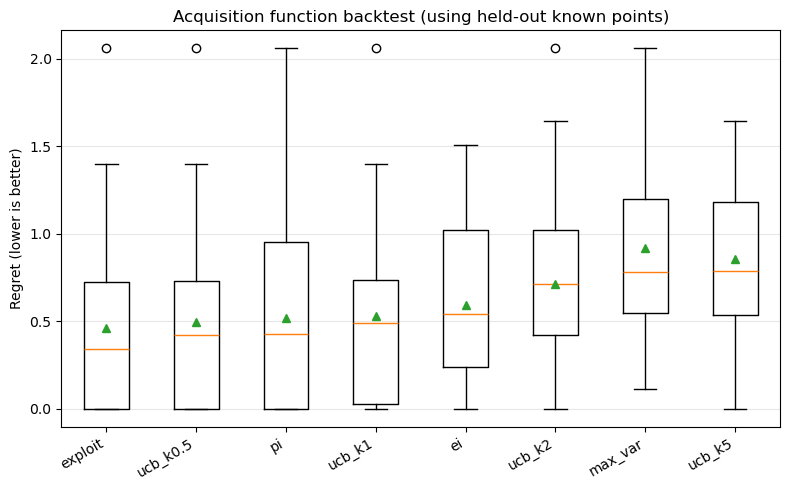

In [21]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)\n")

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## Compare kappa values -- the deciding cell

Fits ONE shared GP and shows where each candidate `kappa` would propose to search *right now*, so differences between rows are purely down to `kappa` rather than GP-refit noise.

The criterion used here is **upper-bound contact**. `kappa=0.5` is the largest value whose proposal touches no upper bound; at `kappa >= 1` the proposal starts pinning coordinates to `pad_fraction`'s arbitrary ceiling, at which point the padding rather than the model is choosing them.

Lower-bound contact is reported separately and is **not** disqualifying: every axis has a lower bound of `0.0`, which is a real domain constraint, so a coordinate sitting there is a genuine "as low as allowed" prediction. x4 does exactly that, and independently has the strongest negative rank correlation with `y` (-0.609).

   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 | [0.512,0.298,0.549,0.774,0.021] |    -0.4060 |    -0.4060 |    0.1228 |          0.2731
    0.25 | [0.506,0.283,0.563,0.769,0.   ] |    -0.3733 |    -0.4073 |    0.1360 |          0.3015
     0.5 | [0.497,0.265,0.582,0.764,0.   ] |    -0.3383 |    -0.4105 |    0.1442 |          0.3207
       1 | [0.47 ,0.204,0.641,0.744,0.   ] |    -0.2595 |    -0.4350 |    0.1755 |          0.3880
       2 | [0.402,0.   ,0.983,0.653,0.   ] |    -0.0149 |    -0.6645 |    0.3248 |          0.7639
       5 | [1.894,1.749,1.941,1.878,1.781] |     1.8542 |    -1.4892 |    0.6687 |          3.1401

 kappa | UPPER bound (artifact) | lower bound (real floor) | in hull
     0 |                   none |                     none | False
  0.25 |                   none |                      [4] | False
   0.5 |          

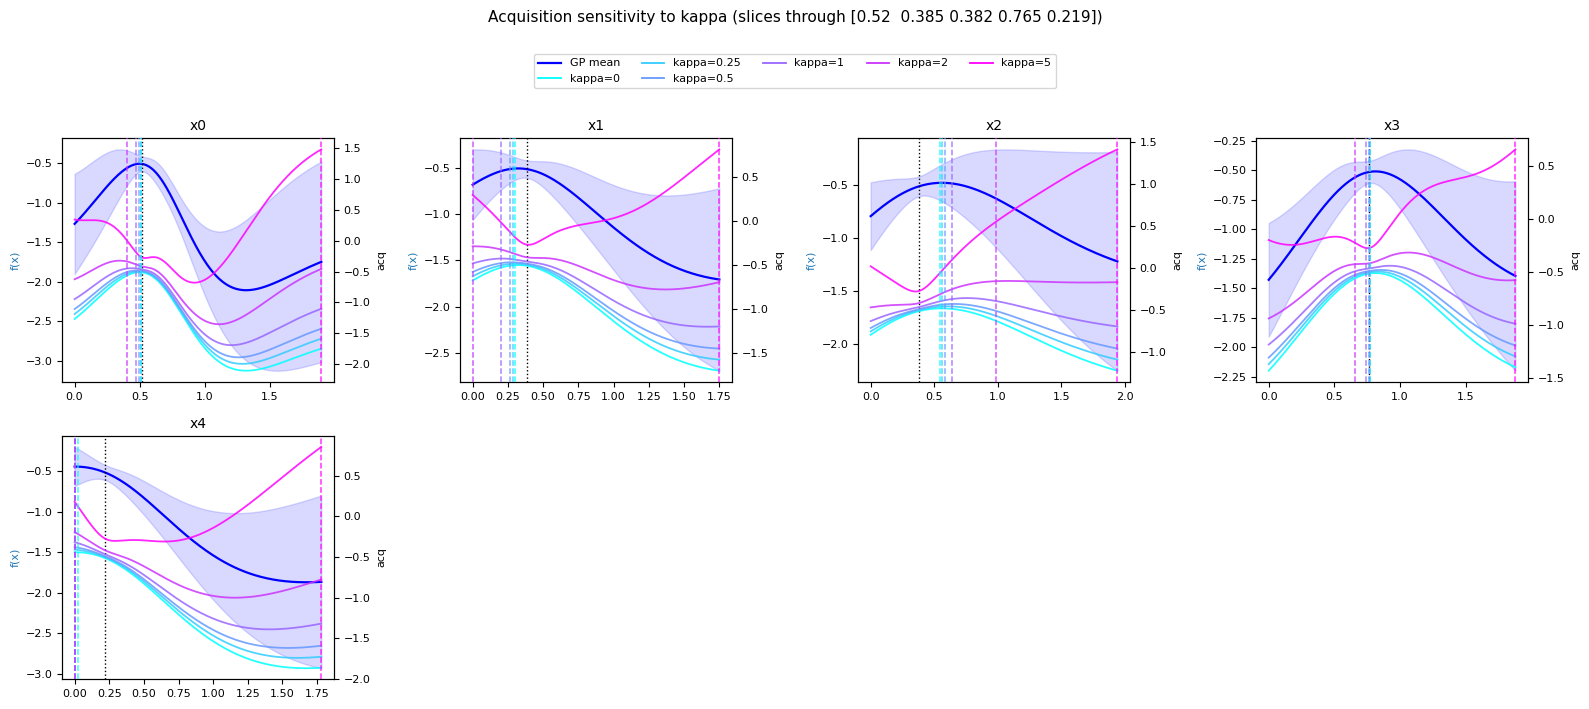


using kappa = 0.5 (dimensionless -- no y-scaling needed)
chosen as the largest kappa whose proposal touches no UPPER bound


In [22]:
kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.0, 0.25, 0.5, 1.0, 2.0, 5.0],
                                      maximize=True, n_restarts=40, random_state=0)
print_kappa_comparison(kappa_rows)


def bound_report(p):
    """Upper-bound contact is a pad_fraction artifact; lower is the X >= 0 floor."""
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print(f"\n{'kappa':>6} | {'UPPER bound (artifact)':>22} | {'lower bound (real floor)':>24} | in hull")
for row in kappa_rows:
    up, lo = bound_report(row["x_next"])
    ih = bool(hull.find_simplex(row["x_next"]) >= 0) if hull is not None else None
    print(f"{row['kappa']:6g} | {str(up) if up else 'none':>22}"
          f" | {str(lo) if lo else 'none':>24} | {ih}")

fig = plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# Committed choice -- reused by the proposal, the slice plot, and the diagnostics
# replay below, so they can't silently drift apart.
KAPPA = 0.5
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed)")
print("chosen as the largest kappa whose proposal touches no UPPER bound")

## Propose the next point

Unrestricted over all five axes, since none is flat.

The checks separate the two kinds of bound contact, and report convex-hull membership for information only -- at D=5 with 21 points nearly every observation is a hull vertex, so almost any proposal reads as outside it.

In [23]:
x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition="ucb",
    kappa=KAPPA,        # see the comparison above
    maximize=True,
    n_restarts=60,
    random_state=0,
)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.6f}, predicted std: {sigma[0]:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu[0] - y.max():+.6f}")

up, lo = bound_report(x_next)
print("\non UPPER bound (pad_fraction artifact -- bad):", up or "none")
if up:
    print("*** pad_fraction is choosing those coordinates, not the model.")
    print("    Lower kappa until the proposal comes off the upper bounds. ***")
print("on lower bound (X >= 0 floor -- legitimate):", lo or "none")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
if hull is not None:
    print(f"inside the convex hull: {bool(hull.find_simplex(x_next) >= 0)}"
          "  (weak test at D=5 -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (5, 2)) ---
x_next: [0.497078 0.264731 0.582415 0.764018 0.      ]
1.4**2 * Matern(length_scale=[0.295, 0.578, 0.604, 0.527, 0.581], nu=2.5) + WhiteKernel(noise_level=0.00522)
GP predicted mean: -0.410454, predicted std: 0.144212
current best observed y: -0.511982  -> predicted improvement: +0.101528

on UPPER bound (pad_fraction artifact -- bad): none
on lower bound (X >= 0 floor -- legitimate): [4]
outside the observed range on its own axis: none
inside the convex hull: False  (weak test at D=5 -- see above)

distance from the incumbent: 0.320655
nearest 3 observations to x_next:
  dist=0.3101  y=-0.714265  X=[0.728 0.155 0.733 0.694 0.056]
  dist=0.3207  y=-0.511982  X=[0.52  0.385 0.382 0.765 0.219]
  dist=0.4290  y=-0.935757  X=[0.783 0.536 0.443 0.86  0.01 ]


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other four dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`, green is UCB.

Unlike functions 3, 5, 7 and 8, expect **no flat panels** here -- every axis moves the mean by a comparable amount, which is why the search is unrestricted. The x0 panel should look the most structured (shortest length-scale) despite x0 having almost no monotone correlation with `y`.

This is a *partial* view: it shows the GP along each axis near the best point, not interactions between dimensions.

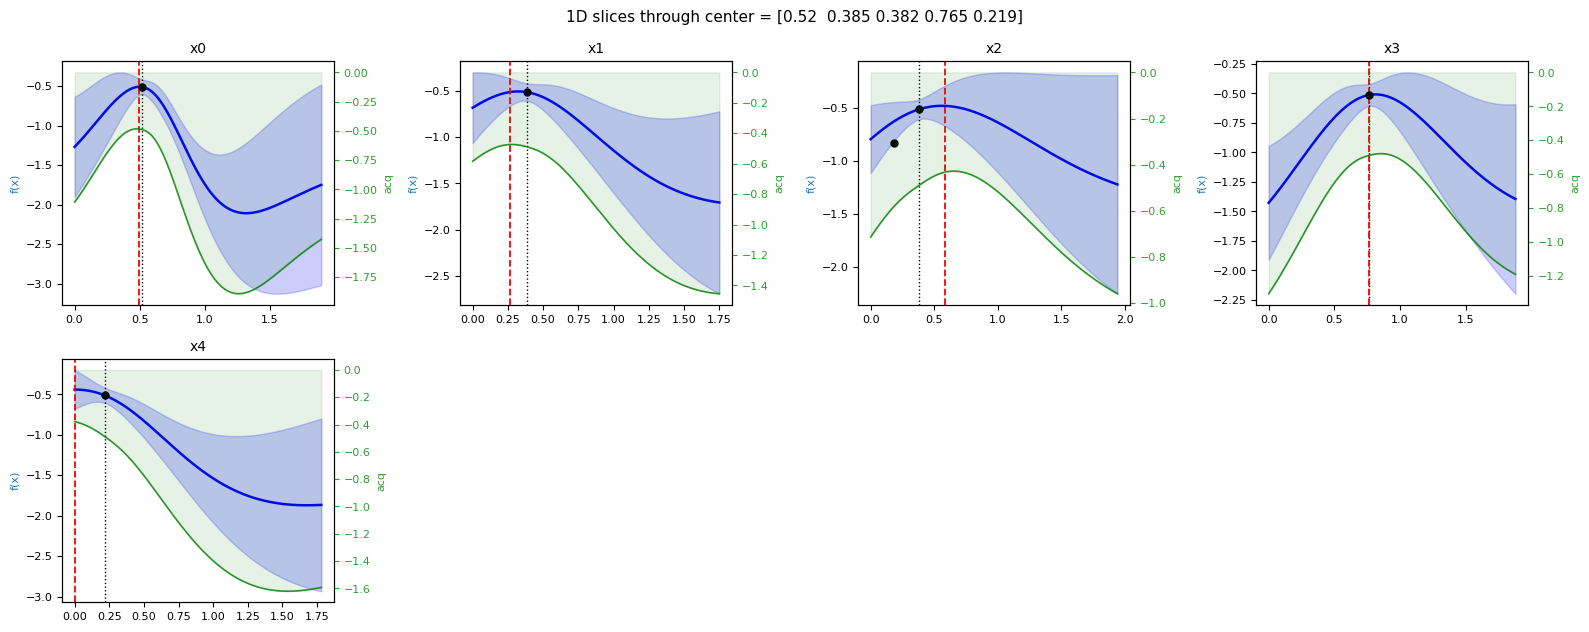

In [24]:
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. At D=5 this is the main way to judge the surrogate, since the fitted surface can't be inspected directly.

Read the error bars rather than the correlation. Unlike functions 4 and 5, the worst-predicted point here should be an *initial* observation rather than the newly collected one -- the new point was predicted to 0.6 sigma before it arrived, so it is not the model's weak spot.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_pro

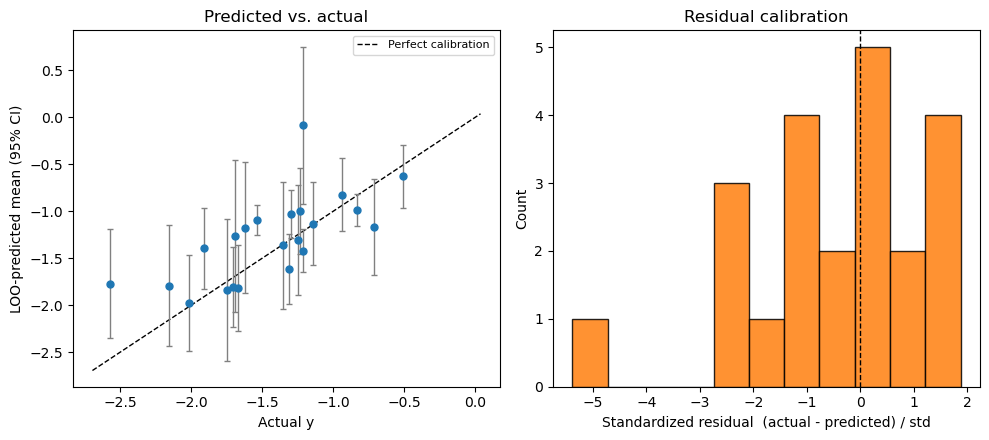

points inside their own 95% LOO interval: 17/22
worst-predicted: index 21 -> true -1.214796, predicted -0.087017 (std 0.428703)
is that the newly collected point? False


In [25]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})")
print("is that the newly collected point?", worst == n_initial)

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

**`domain_grid_n` MUST be lowered past D=4.** Its `domain_mean_std` field averages the posterior std over a dense grid built as `domain_grid_n ** D` points, and the default `domain_grid_n=40` means:

| D | grid points at the default | array size |
|---|---|---|
| 4 (functions 4, 5) | 2.6e6 | 0.08 GB -- fine |
| **5 (this one)** | **1.0e8** | **4.1 GB -- kills the kernel** |
| 6 (function 7) | 4.1e9 | 197 GB |
| 8 (function 8) | 6.6e12 | 419,000 GB |

The first run of this notebook died exactly there. The cell below sizes the grid so `domain_grid_n ** D` stays around 200,000 regardless of `D`, which gives `domain_grid_n=11` here. That makes `domain_mean_std` a coarser estimate of domain-average uncertainty -- it is still a fair basis for comparing one iteration against another, but don't compare its absolute value against a run that used a different grid.

Two further caveats, as on the other notebooks. The setting is taken from `KAPPA` so it can't drift from what the proposal used -- but the single recorded observation came from the old week-1 sweep (`pi`/`xi=0.01`), so its replayed acquisition value describes a decision never made that way; treat that column as meaningless until the history is UCB throughout. And it assumes row order is true chronological order.

`plot_bo_diagnostics` is skipped (it hard-codes a 2D scatter panel and this is 5D); the trend plots below are dimension-agnostic and gated on having a few completed iterations.

In [26]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default of
# 40 is 40**5 = 1.0e8 points (~4 GB) at D=5 and WILL kill the kernel. Size it so
# the grid stays ~200k points whatever D is.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")

history = None
if len(new_y) == 0:
    print("\nNo observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition="ucb", kappa=KAPPA, maximize=True,
                                             domain_grid_n=DOMAIN_GRID_N)
    print("\nBest y so far:", np.nanmax(history["y"]))
    print("completed iterations beyond the initial batch:", len(new_y))

    if len(new_y) >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend\n"
              "plots to say anything. Skipping them; the raw fields are below.")

domain_grid_n = 11 -> 161,051 grid points (the default 40 would be 102,400,000)

Best y so far: -0.5119821356901731
completed iterations beyond the initial batch: 2

Only 2 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


## Raw diagnostic fields

In [27]:
if history is not None:
    print("y:", np.round(history["y"], 5))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\npred_mean at proposal time:", history["pred_mean"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.71426 -1.20996 -1.6722  -1.53606 -0.82924 -1.24705 -1.23379 -1.69434
 -2.57117 -1.30912 -1.14478 -1.91268 -1.62284 -1.35668 -2.01843 -1.70256
 -1.29425 -0.93576 -2.15577 -1.74688 -0.51198 -1.2148 ]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2.]

acq_value (NaN = initial batch; see the caveat above): [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan -0.52147948  0.12733528]

pred_mean at proposal time: [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan -0.59631647 -0.08701605]

domain_mean_std: [       nan        nan        nan        nan        nan        nan
       

In [28]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.497078-0.264731-0.582415-0.764018-0.000000

full precision (use for next week's new_X):
0.49707819359032634-0.2647311219138715-0.5824149522356864-0.7640181811683764-0.0
